# Archival Photo Vision Model Evaluation

This notebook evaluates the results from testing multiple vision models on historical photographs from Wikimedia Commons.

## Objectives
- Compare model performance across different evaluation criteria
- Analyze cost-effectiveness of each model
- Generate final recommendations for archival photo cataloging

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# Set up plotting style
plt.style.use('default')
sns.set_palette('husl')

# Define paths
DATA_DIR = Path('../data')
REPORTS_DIR = Path('../reports')
RESULTS_FILE = DATA_DIR / 'results/random_photo_test.csv'
METADATA_FILE = DATA_DIR / 'metadata.json'

## Load and Explore Data

In [4]:
# Load results data
if RESULTS_FILE.exists():
    results_df = pd.read_csv(RESULTS_FILE)
    print(f"Loaded {len(results_df)} results")
    print(f"Columns: {list(results_df.columns)}")
    display(results_df.head())
else:
    print("Results file not found. Run the model testing script first.")

Loaded 4 results
Columns: ['photo_id', 'test_timestamp', 'test_type', 'wikimedia_title', 'decade', 'photo_type', 'description', 'model', 'model_name', 'success', 'error_message', 'processing_time', 'input_tokens', 'output_tokens', 'total_tokens', 'cost_usd', 'response_length', 'full_response', 'model_timestamp']


,photo_id,test_timestamp,test_type,wikimedia_title,decade,photo_type,description,model,model_name,success,error_message,processing_time,input_tokens,output_tokens,total_tokens,cost_usd,response_length,full_response,model_timestamp
0,photo_0c4b41ea.jpg,2025-09-15T19:06:44.299013,random_single,NaN,NaN,NaN,NaN,gpt-4o,openai/gpt-4o,True,NaN,17.363666,1200,410,1610,0.012150,2068,**People:**\n- There are no visible people in ...,2025-09-15T19:07:01.662710
1,photo_0c4b41ea.jpg,2025-09-15T19:06:44.299013,random_single,NaN,NaN,NaN,NaN,gpt-4o-mini,openai/gpt-4o-mini,True,NaN,8.551900,36930,449,37379,0.005809,2233,### Detailed Description for Archival Catalogi...,2025-09-15T19:07:11.218250
2,photo_0c4b41ea.jpg,2025-09-15T19:06:44.299013,random_single,NaN,NaN,NaN,NaN,claude-3.5-sonnet,anthropic/claude-3.5-sonnet,True,NaN,13.157618,1643,347,1990,0.010134,1721,This photograph appears to be a cityscape view...,2025-09-15T19:07:25.379937
3,photo_0c4b41ea.jpg,2025-09-15T19:06:44.299013,random_single,NaN,NaN,NaN,NaN,gemini-1.5-flash,google/gemini-1.5-flash,False,Error code: 400 - {'error': {'message': 'googl...,0.351017,0,0,0,0.000000,0,NaN,2025-09-15T19:07:26.736246


In [6]:
# Load metadata
if METADATA_FILE.exists():
    with open(METADATA_FILE, 'r') as f:
        metadata = json.load(f)
    
    metadata_df = pd.DataFrame(metadata)
    print(f"Loaded metadata for {len(metadata_df)} photos")
    display(metadata_df.head())
else:
    print("Metadata file not found.")

Loaded metadata for 40 photos


,wikimedia_title,url,timestamp,user,width,height,size,mime,description,date_taken,license,author,categories,decade,photo_type,download_date,source_category,local_filename
0,File:X-2 After Drop from B-50 Mothership - GPN...,https://upload.wikimedia.org/wikipedia/commons...,2020-03-17T01:21:38Z,Kees08,3000,2297,745570,image/jpeg,The Bell Aircraft Company X-2 (46-674) drops a...,1955,pd,NACA,"[PD NASA, Boeing B-50 Superfortress, 1950s pho...",1950s,portrait,2025-09-15T18:24:21.672221,Category:1950s photographs of the United States,photo_1a7b38be.jpg
1,"File:Laysan Albatross -4, 42 days old, Kure At...",https://upload.wikimedia.org/wikipedia/commons...,2015-09-26T19:45:04Z,Sumita Roy Dutta,6115,3761,1311079,image/jpeg,<p><b>Creator</b>: unknown\n</p><p><br>\n<b>Lo...,2013-07-19 15:09,NaN,"<a rel=""nofollow"" class=""external text"" href=""...","[Kure Atoll, 1960s photographs of the United S...",2010s,work,2025-09-15T18:24:23.186435,Category:1960s photographs of the United States,photo_493de511.jpg
2,"File:Elvira Puccini, Giacomo Puccini, Antonio ...",https://upload.wikimedia.org/wikipedia/commons...,2020-07-15T10:57:50Z,LutiV,1368,956,491515,image/jpeg,"Portrait of Elvira Puccini, Giacomo Puccini, A...","1900<div style=""display: none;"">date QS:P571,+...",cc-by-sa-4.0,"<div class=""fn value"">\nUnknown author<span st...","[Giacomo Puccini, Antonio Puccini, Elvira Pucc...",1900s,portrait,2025-09-15T18:24:25.631488,Category:20th-century portrait photographs,photo_9f711633.jpg
3,"File:""The NOVEMBER Victor Records are here"" an...",https://upload.wikimedia.org/wikipedia/commons...,2020-08-11T02:29:45Z,Tibet Nation,1619,1296,2098446,image/tiff,<i>Title:</i> Queen Quality Boot Shop\n<i>Abst...,"between 1920 and 1921<div style=""display: none...",pd,National Photo Company Collection,"[Victor Records, Images from the Library of Co...",1920s,building,2025-09-15T18:24:28.294230,Category:1920s photographs of the United States,photo_371e47a9.tif
4,File:(Portrait of Lena Horne and Lennie Hayton...,https://upload.wikimedia.org/wikipedia/commons...,2017-08-23T13:14:57Z,Ras67,912,952,158335,image/jpeg,"<p>Gottlieb, William P., 1917-, photographer.\...",1946,pd,"<a rel=""nofollow"" class=""external text"" href=""...","[Lena Horne, Lennie Hayton, Images with annota...",1940s,portrait,2025-09-15T18:24:31.020792,Category:1940s photographs of the United States,photo_c90ccb7a.jpg


## Performance Analysis

Models tested: ['gpt-4o' 'gpt-4o-mini' 'claude-3.5-sonnet' 'gemini-1.5-flash']


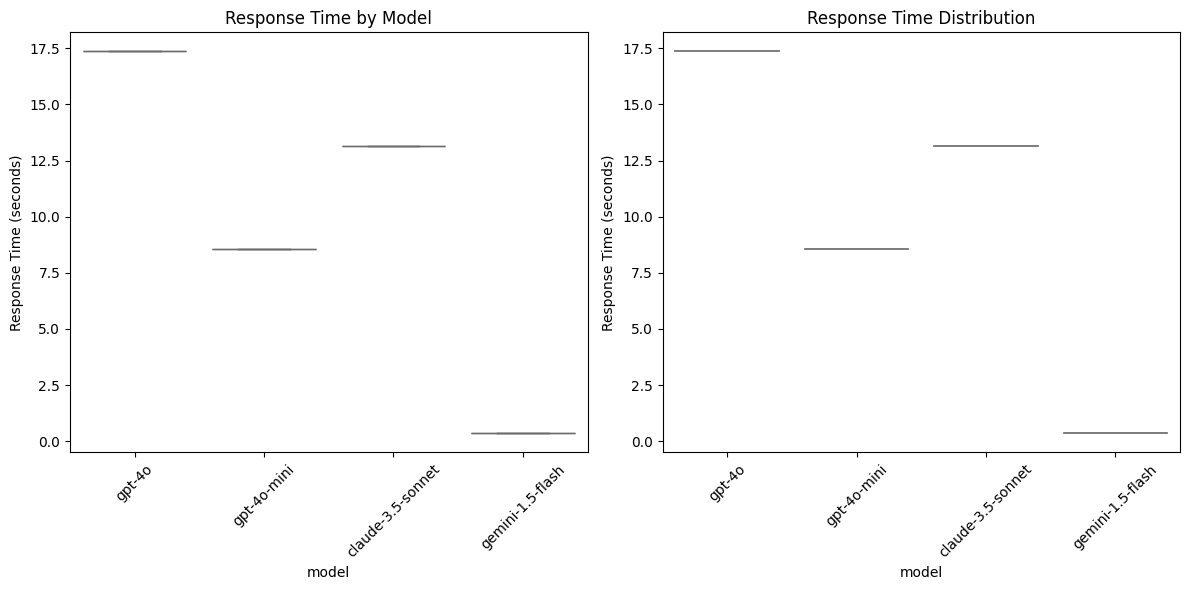

In [7]:
# Model performance comparison
if 'results_df' in locals():
    models = results_df['model'].unique()
    print(f"Models tested: {models}")
    
    # Response time analysis
    if 'processing_time' in results_df.columns:
        plt.figure(figsize=(12, 6))
        
        plt.subplot(1, 2, 1)
        sns.boxplot(data=results_df, x='model', y='processing_time')
        plt.title('Response Time by Model')
        plt.ylabel('Response Time (seconds)')
        plt.xticks(rotation=45)
        
        plt.subplot(1, 2, 2)
        sns.violinplot(data=results_df, x='model', y='processing_time')
        plt.title('Response Time Distribution')
        plt.ylabel('Response Time (seconds)')
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.savefig(REPORTS_DIR / 'response_time_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()

Cost Analysis by Model:


,Mean Cost,Median Cost,Total Cost,Photo Count,Cost per 1000 Photos
model,,,,,
claude-3.5-sonnet,0.010134,0.010134,0.010134,1,10.13
gemini-1.5-flash,0.000000,0.000000,0.000000,1,0.00
gpt-4o,0.012150,0.012150,0.012150,1,12.15
gpt-4o-mini,0.005809,0.005809,0.005809,1,5.81


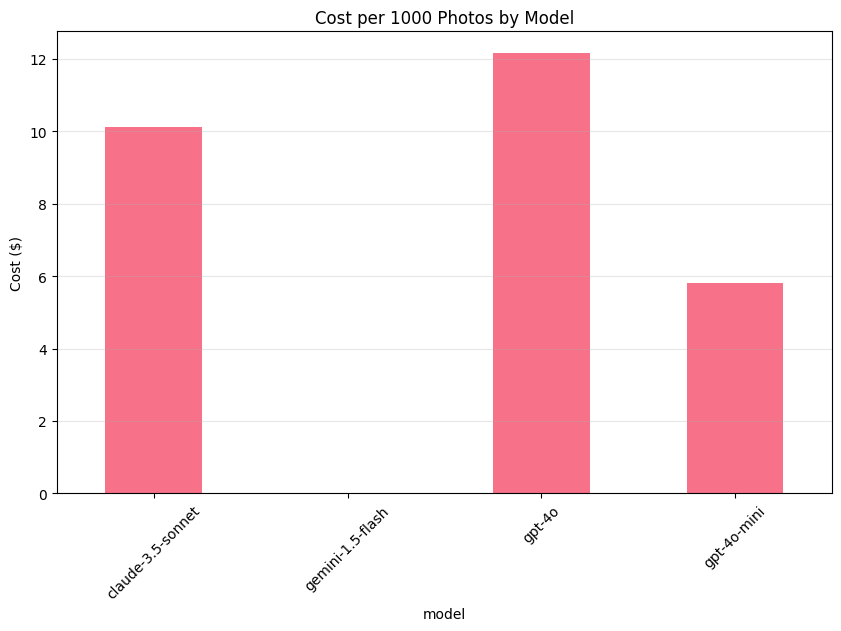

In [8]:
# Cost analysis
if 'results_df' in locals() and 'cost_usd' in results_df.columns:
    cost_summary = results_df.groupby('model')['cost_usd'].agg(['mean', 'median', 'sum', 'count'])
    cost_summary.columns = ['Mean Cost', 'Median Cost', 'Total Cost', 'Photo Count']
    cost_summary['Cost per 1000 Photos'] = (cost_summary['Mean Cost'] * 1000).round(2)
    
    print("Cost Analysis by Model:")
    display(cost_summary)
    
    # Visualize cost comparison
    plt.figure(figsize=(10, 6))
    cost_summary['Cost per 1000 Photos'].plot(kind='bar')
    plt.title('Cost per 1000 Photos by Model')
    plt.ylabel('Cost ($)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.savefig(REPORTS_DIR / 'cost_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

## Quality Evaluation

Manual scoring framework for evaluating description quality across key criteria.

In [9]:
# Quality scoring template
evaluation_criteria = [
    'accuracy',           # Correct identification of visible elements
    'detail_level',       # Comprehensiveness of description
    'historical_context', # Recognition of time period indicators
    'archival_usefulness',# Practical value for cataloging
    'edge_case_handling'  # Performance on damaged/unclear photos
]

def create_evaluation_template():
    """Create template for manual evaluation"""
    try:
        if results_df is None:
            print("❌ No results data available for template creation")
            return None
        
        # Get successful results only for evaluation
        successful_results = results_df[results_df['success'] == True]
        
        if successful_results.empty:
            print("❌ No successful results available for template creation")
            return None
        
        # Find the response column (try different possible names)
        response_col = None
        possible_cols = ['full_response', 'response', 'description']
        for col in possible_cols:
            if col in successful_results.columns:
                response_col = col
                break
        
        if response_col is None:
            print(f"❌ No response column found. Available columns: {list(successful_results.columns)}")
            return None
        
        # Create evaluation template
        eval_template = successful_results[['photo_id', 'model', response_col]].copy()
        eval_template = eval_template.rename(columns={response_col: 'description'})
        
        # Add scoring columns (1-5 scale)
        for criteria in evaluation_criteria:
            eval_template[criteria] = np.nan
        
        eval_template['notes'] = ''
        
        # Ensure reports directory exists
        REPORTS_DIR.mkdir(parents=True, exist_ok=True)
        
        # Save template for manual scoring
        template_file = REPORTS_DIR / 'evaluation_template.csv'
        eval_template.to_csv(template_file, index=False)
        
        print(f"✅ Evaluation template saved to {template_file}")
        print(f"📊 Template includes {len(eval_template)} successful test results")
        print(f"📝 Using '{response_col}' column for descriptions")
        return eval_template
        
    except Exception as e:
        print(f"❌ Error creating evaluation template: {e}")
        print(f"   Available data shape: {results_df.shape if results_df is not None else 'None'}")
        if results_df is not None:
            print(f"   Available columns: {list(results_df.columns)}")
        return None

eval_template = create_evaluation_template()

✅ Evaluation template saved to ../reports/evaluation_template.csv
📊 Template includes 3 successful test results
📝 Using 'full_response' column for descriptions


In [ ]:
# Load completed evaluations (if available)
eval_file = REPORTS_DIR / 'completed_evaluations.csv'

if eval_file.exists():
    evaluations = pd.read_csv(eval_file)
    print(f"Loaded {len(evaluations)} completed evaluations")
    
    # Calculate average scores by model
    score_columns = [col for col in evaluations.columns if col in evaluation_criteria]
    model_scores = evaluations.groupby('model')[score_columns].mean()
    
    print("\nAverage Scores by Model (1-5 scale):")
    display(model_scores.round(2))
    
    # Radar chart for model comparison
    plt.figure(figsize=(10, 8))
    angles = np.linspace(0, 2*np.pi, len(score_columns), endpoint=False).tolist()
    angles += angles[:1]  # Complete the circle
    
    for model in model_scores.index:
        values = model_scores.loc[model].tolist()
        values += values[:1]  # Complete the circle
        plt.polar(angles, values, 'o-', linewidth=2, label=model)
    
    plt.xticks(angles[:-1], score_columns)
    plt.ylim(0, 5)
    plt.title('Model Performance Comparison\n(Higher scores = Better)')
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    plt.savefig(REPORTS_DIR / 'model_radar_chart.png', dpi=300, bbox_inches='tight')
    plt.show()
    
else:
    print(f"No completed evaluations found at {eval_file}")
    print("Please complete the manual evaluation using the template above.")

## Photo Category Analysis

In [ ]:
# Analyze performance by photo category
if 'metadata_df' in locals() and 'evaluations' in locals():
    # Merge evaluation data with metadata
    merged_data = evaluations.merge(metadata_df, on='photo_id', how='left')
    
    if 'category' in merged_data.columns:
        category_performance = merged_data.groupby(['model', 'category'])[score_columns].mean()
        
        print("Performance by Photo Category:")
        display(category_performance.round(2))
        
        # Heatmap of performance by category
        plt.figure(figsize=(12, 8))
        for i, model in enumerate(merged_data['model'].unique()):
            plt.subplot(2, 2, i+1)
            model_data = category_performance.loc[model]
            sns.heatmap(model_data.T, annot=True, cmap='RdYlGn', vmin=1, vmax=5, 
                       cbar_kws={'label': 'Score (1-5)'})
            plt.title(f'{model} Performance by Category')
            plt.xlabel('Photo Category')
            plt.ylabel('Evaluation Criteria')
        
        plt.tight_layout()
        plt.savefig(REPORTS_DIR / 'category_performance_heatmap.png', dpi=300, bbox_inches='tight')
        plt.show()

## Final Recommendations

In [ ]:
# Generate comprehensive recommendations
def generate_recommendations():
    recommendations = {
        'timestamp': pd.Timestamp.now().isoformat(),
        'summary': {},
        'model_rankings': {},
        'cost_analysis': {},
        'workflow_recommendations': []
    }
    
    if 'evaluations' in locals() and 'cost_summary' in locals():
        # Overall model ranking
        overall_scores = evaluations.groupby('model')[score_columns].mean().mean(axis=1)
        cost_effectiveness = overall_scores / cost_summary['Cost per 1000 Photos']
        
        recommendations['model_rankings'] = {
            'by_quality': overall_scores.sort_values(ascending=False).to_dict(),
            'by_cost': cost_summary['Cost per 1000 Photos'].sort_values().to_dict(),
            'by_cost_effectiveness': cost_effectiveness.sort_values(ascending=False).to_dict()
        }
        
        # Top recommendations
        best_quality = overall_scores.idxmax()
        most_cost_effective = cost_effectiveness.idxmax()
        cheapest = cost_summary['Cost per 1000 Photos'].idxmin()
        
        recommendations['summary'] = {
            'best_quality_model': best_quality,
            'most_cost_effective_model': most_cost_effective,
            'cheapest_model': cheapest,
            'total_photos_tested': len(evaluations['photo_id'].unique()),
            'models_tested': list(evaluations['model'].unique())
        }
        
        # Workflow recommendations
        recommendations['workflow_recommendations'] = [
            f"For highest quality descriptions: Use {best_quality}",
            f"For best cost-effectiveness: Use {most_cost_effective}",
            f"For budget-conscious processing: Use {cheapest}",
            "Implement quality control sampling (10% manual review)",
            "Pre-process images to optimize for API requirements",
            "Batch process during off-peak hours for better rates"
        ]
    
    # Save recommendations
    with open(REPORTS_DIR / 'final_recommendations.json', 'w') as f:
        json.dump(recommendations, f, indent=2)
    
    print("Final Recommendations Generated:")
    print(json.dumps(recommendations, indent=2))
    
    return recommendations

recommendations = generate_recommendations()

## Export Results

In [ ]:
# Generate final report
def create_final_report():
    report_content = f"""
# Archival Photo Vision Model Evaluation Report

**Generated:** {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}

## Executive Summary

This report evaluates the performance of multiple vision models for archival photo cataloging.

### Key Findings

"""
    
    if 'recommendations' in locals():
        summary = recommendations['summary']
        report_content += f"""
- **Photos Tested:** {summary.get('total_photos_tested', 'N/A')}
- **Models Evaluated:** {', '.join(summary.get('models_tested', []))}
- **Best Quality Model:** {summary.get('best_quality_model', 'N/A')}
- **Most Cost-Effective:** {summary.get('most_cost_effective_model', 'N/A')}
- **Most Economical:** {summary.get('cheapest_model', 'N/A')}

### Recommendations

"""
        for rec in recommendations.get('workflow_recommendations', []):
            report_content += f"- {rec}\n"
    
    report_content += """

## Detailed Analysis

See accompanying visualizations and data files for detailed performance metrics.

### Files Generated
- `final_recommendations.json` - Machine-readable recommendations
- `evaluation_template.csv` - Template for manual scoring
- `response_time_analysis.png` - Performance timing analysis
- `cost_comparison.png` - Cost analysis visualization
- `model_radar_chart.png` - Multi-criteria comparison
- `category_performance_heatmap.png` - Performance by photo type

## Next Steps

1. Implement recommended model in production workflow
2. Establish quality control procedures
3. Monitor ongoing performance and costs
4. Refine prompts based on real-world usage
"""
    
    with open(REPORTS_DIR / 'evaluation_report.md', 'w') as f:
        f.write(report_content)
    
    print(f"Final report saved to {REPORTS_DIR / 'evaluation_report.md'}")
    print("\nAll evaluation outputs saved to reports/ directory")

create_final_report()